In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
os.makedirs(VISUALS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded successfully
Shape: (1119, 20)
Columns: ['time', 'base', 'county', 'road', 'place', 'mv_involved', 'accident_details', 'victim_name', 'gender', 'age', 'cause_code', 'victim_type', 'num_victims', 'date', 'hour', 'time_of_day', 'age_group', 'victim_category', 'is_fatal', 'gender_clean']


In [2]:
print("="*55)
print("TARGET VARIABLE — num_victims")
print("="*55)
print(f"\nTotal records     : {len(df)}")
print(f"Missing values    : {df['num_victims'].isnull().sum()}")
print(f"Min victims       : {df['num_victims'].min()}")
print(f"Max victims       : {df['num_victims'].max()}")
print(f"Mean victims      : {df['num_victims'].mean():.2f}")
print(f"Median victims    : {df['num_victims'].median():.2f}")
print(f"\nValue distribution:")
print(df['num_victims'].value_counts().sort_index())

TARGET VARIABLE — num_victims

Total records     : 1119
Missing values    : 0
Min victims       : 1
Max victims       : 18
Mean victims      : 1.18
Median victims    : 1.00

Value distribution:
num_victims
1     1025
2       60
3       15
4        5
5        5
6        3
8        3
9        1
17       1
18       1
Name: count, dtype: int64


In [3]:
# ── Select features for the model ───────────────────
# We need to encode categorical columns into numbers
# because ML algorithms only understand numbers

le_county  = LabelEncoder()
le_cause   = LabelEncoder()
le_victim  = LabelEncoder()
le_time    = LabelEncoder()

# Fill nulls before encoding
df['county']          = df['county'].fillna('Unknown')
df['cause_code']      = df['cause_code'].fillna('Unknown')
df['victim_category'] = df['victim_category'].fillna('Unknown')
df['time_of_day']     = df['time_of_day'].fillna('Unknown')
df['hour']            = df['hour'].fillna(0)

# Encode each categorical column
df['county_encoded']  = le_county.fit_transform(df['county'])
df['cause_encoded']   = le_cause.fit_transform(
                         df['cause_code'].astype(str))
df['victim_encoded']  = le_victim.fit_transform(df['victim_category'])
df['time_encoded']    = le_time.fit_transform(df['time_of_day'])

print("Encoding complete")
print(f"\nCounty categories  : {len(le_county.classes_)}")
print(f"Cause categories   : {len(le_cause.classes_)}")
print(f"Victim categories  : {len(le_victim.classes_)}")
print(f"Time categories    : {len(le_time.classes_)}")

Encoding complete

County categories  : 43
Cause categories   : 74
Victim categories  : 7
Time categories    : 5


In [4]:
# ── Define features (X) and target (y) ──────────────
features = [
    'hour',
    'county_encoded',
    'cause_encoded',
    'victim_encoded',
    'time_encoded'
]

feature_names = [
    'Hour of Day',
    'County',
    'Cause Code',
    'Victim Type',
    'Time of Day'
]

# Drop rows with missing target
df_model = df[features + ['num_victims']].dropna()

X = df_model[features]
y = df_model['num_victims']

print("="*55)
print("MODEL DATASET SUMMARY")
print("="*55)
print(f"Total records     : {len(df_model)}")
print(f"Features          : {len(features)}")
print(f"Target variable   : num_victims")
print(f"\nFeature shapes    : {X.shape}")
print(f"Target shape      : {y.shape}")
print(f"\nTarget stats:")
print(y.describe())

MODEL DATASET SUMMARY
Total records     : 1119
Features          : 5
Target variable   : num_victims

Feature shapes    : (1119, 5)
Target shape      : (1119,)

Target stats:
count    1119.000000
mean        1.180518
std         0.964270
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        18.000000
Name: num_victims, dtype: float64


In [5]:
# ── Split data 80% train / 20% test ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print("="*55)
print("TRAIN / TEST SPLIT")
print("="*55)
print(f"Training samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting target distribution:")
print(y_test.value_counts().sort_index())

TRAIN / TEST SPLIT
Training samples  : 895
Testing samples   : 224

Training target distribution:
num_victims
1     818
2      53
3      10
4       2
5       4
6       3
8       3
9       1
18      1
Name: count, dtype: int64

Testing target distribution:
num_victims
1     207
2       7
3       5
4       3
5       1
17      1
Name: count, dtype: int64


In [6]:
# ── Train Linear Regression model ───────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Make predictions ─────────────────────────────────
y_pred = model.predict(X_test)

# ── Round predictions to nearest whole number ────────
y_pred_rounded = np.round(y_pred).astype(int)
y_pred_rounded = np.clip(y_pred_rounded, 1, None)
# clip ensures no prediction goes below 1 victim

print("Model trained successfully")
print(f"\nSample predictions vs actual:")
print(f"{'Actual':<12} {'Predicted':<12} {'Rounded':<12}")
print("-" * 36)
for actual, pred, rounded in zip(
    y_test.values[:10],
    y_pred[:10],
    y_pred_rounded[:10]
):
    print(f"{actual:<12} {pred:<12.2f} {rounded:<12}")

Model trained successfully

Sample predictions vs actual:
Actual       Predicted    Rounded     
------------------------------------
1            1.29         1           
1            1.15         1           
17           1.22         1           
1            1.22         1           
1            1.21         1           
1            1.22         1           
1            1.23         1           
1            1.13         1           
1            1.28         1           
1            1.25         1           


In [7]:
# ── Calculate evaluation metrics ────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("="*55)
print("MODEL EVALUATION — LINEAR REGRESSION")
print("="*55)
print(f"MAE  (Mean Absolute Error)    : {mae:.4f}")
print(f"MSE  (Mean Squared Error)     : {mse:.4f}")
print(f"RMSE (Root Mean Sq Error)     : {rmse:.4f}")
print(f"R2   (R-Squared Score)        : {r2:.4f}")
print()
print("Interpretation:")
print(f"  On average predictions are off by {mae:.2f} victims")
if r2 < 0.3:
    print(f"  R2={r2:.2f} — Low variance explained.")
    print("  This is expected because most accidents")
    print("  involve exactly 1 victim — limited range.")
elif r2 < 0.6:
    print(f"  R2={r2:.2f} — Moderate variance explained.")
else:
    print(f"  R2={r2:.2f} — Good variance explained.")

MODEL EVALUATION — LINEAR REGRESSION
MAE  (Mean Absolute Error)    : 0.3518
MSE  (Mean Squared Error)     : 1.4157
RMSE (Root Mean Sq Error)     : 1.1898
R2   (R-Squared Score)        : -0.0018

Interpretation:
  On average predictions are off by 0.35 victims
  R2=-0.00 — Low variance explained.
  This is expected because most accidents
  involve exactly 1 victim — limited range.


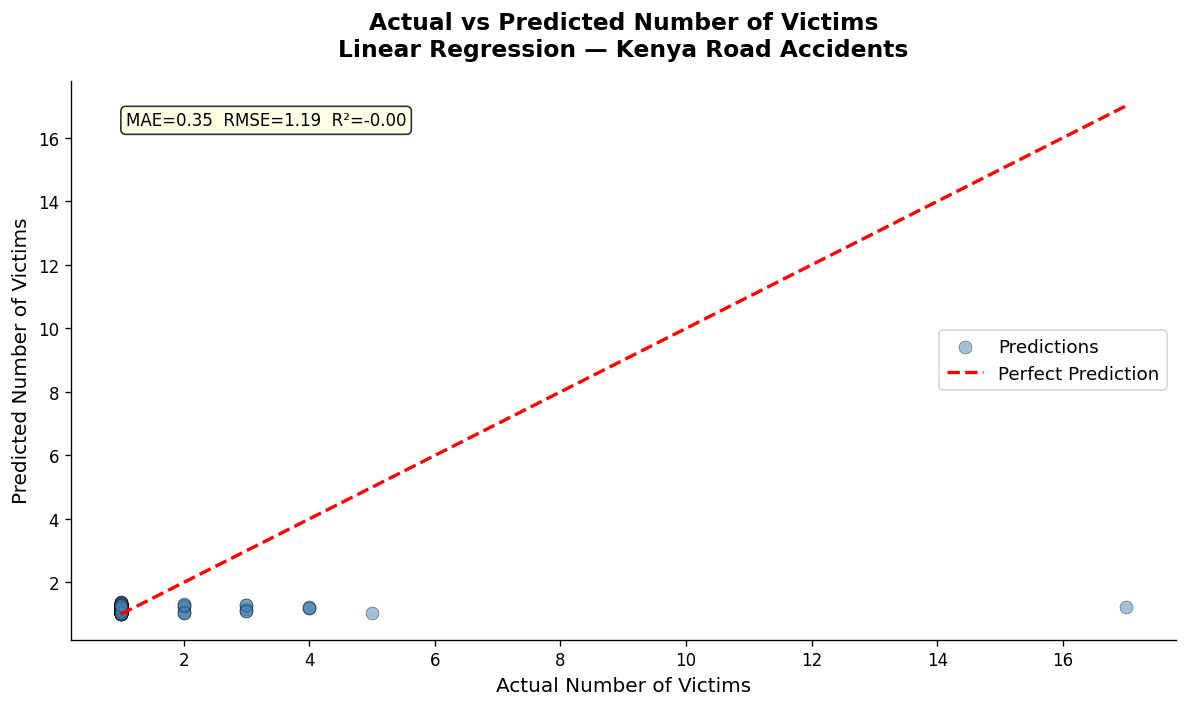

Chart saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    y_test, y_pred,
    color='steelblue', alpha=0.5,
    edgecolors='black', linewidth=0.4,
    s=60, label='Predictions'
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red', linewidth=2,
    linestyle='--', label='Perfect Prediction'
)

ax.set_title('Actual vs Predicted Number of Victims\n'
             'Linear Regression — Kenya Road Accidents',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Actual Number of Victims', fontsize=12)
ax.set_ylabel('Predicted Number of Victims', fontsize=12)
ax.legend(fontsize=11)

# Add metrics annotation
ax.text(0.05, 0.92,
        f'MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.2f}',
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'lr_actual_vs_predicted.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

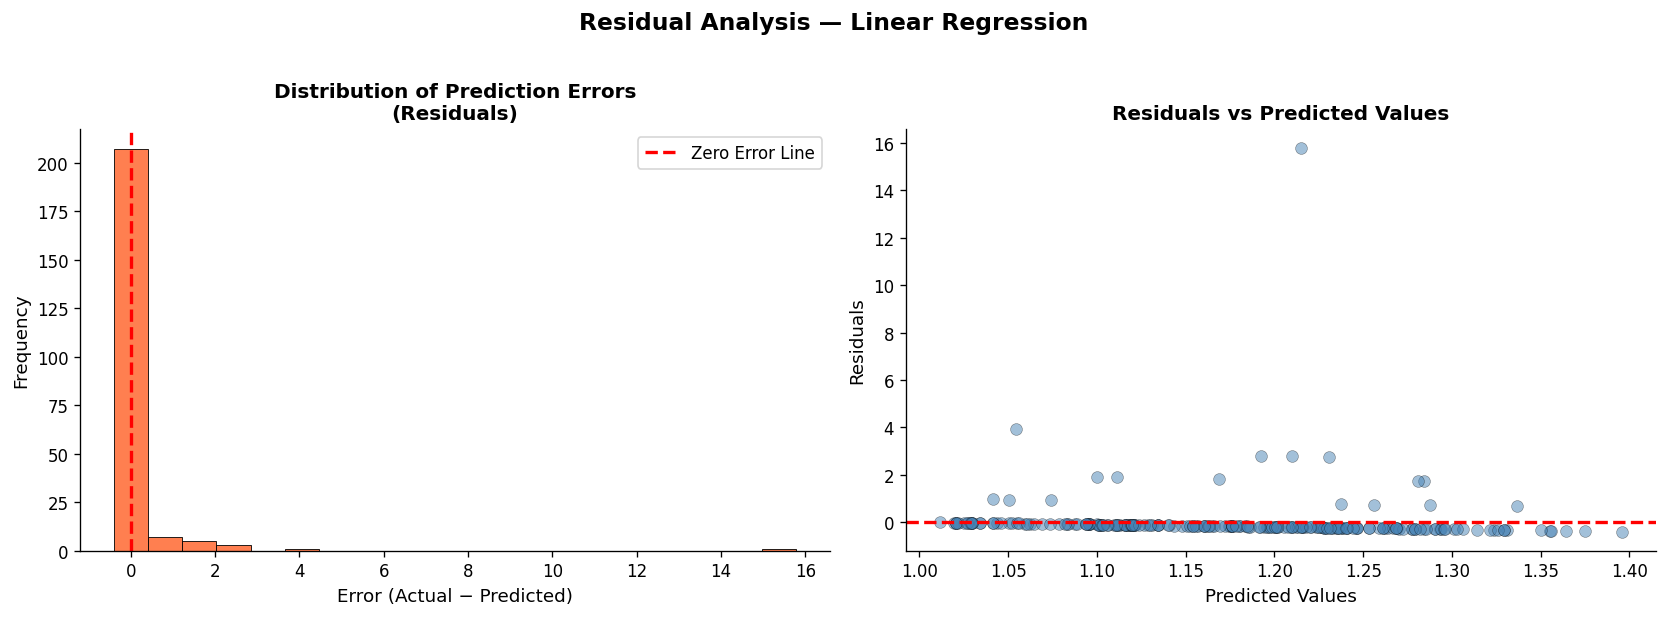

Chart saved


In [9]:
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals histogram
ax1.hist(residuals, bins=20,
         color='coral', edgecolor='black',
         linewidth=0.5)
ax1.axvline(x=0, color='red',
            linewidth=2, linestyle='--',
            label='Zero Error Line')
ax1.set_title('Distribution of Prediction Errors\n'
              '(Residuals)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Error (Actual − Predicted)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend()

# Residuals vs predicted
ax2.scatter(y_pred, residuals,
            color='steelblue', alpha=0.5,
            edgecolors='black', linewidth=0.3, s=50)
ax2.axhline(y=0, color='red',
            linewidth=2, linestyle='--')
ax2.set_title('Residuals vs Predicted Values',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Values', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)

plt.suptitle('Residual Analysis — Linear Regression',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'lr_residuals.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

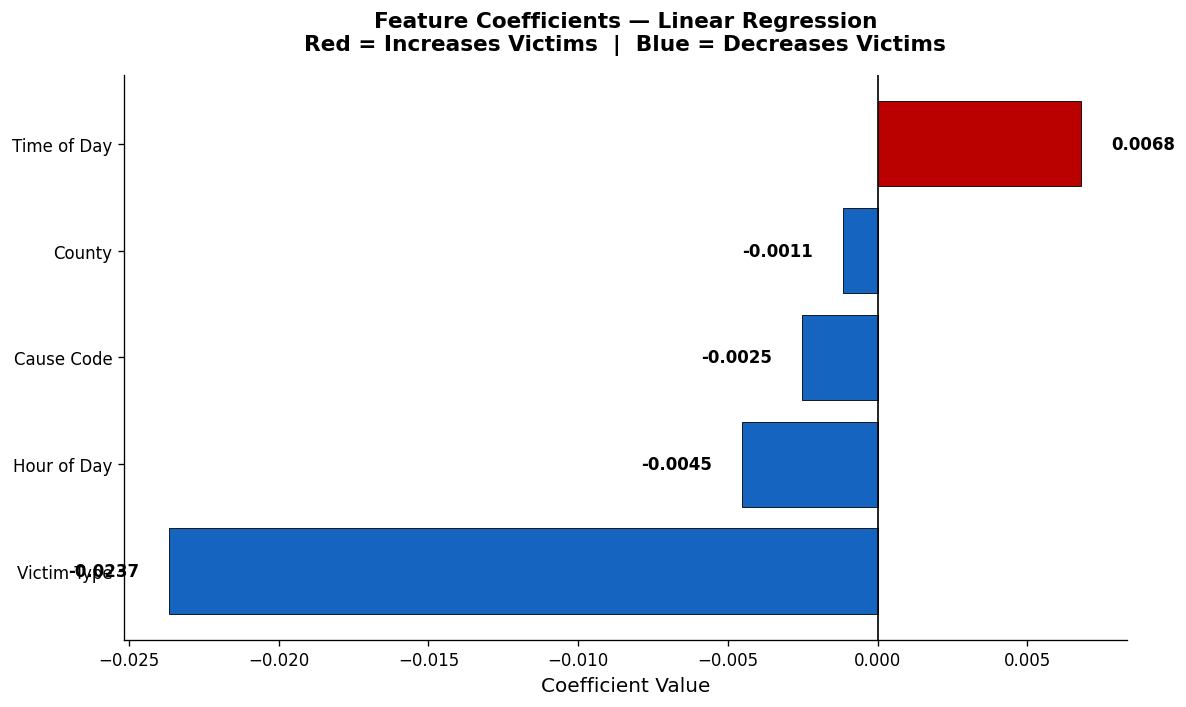

Chart saved


In [10]:
coeff_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

colors = [
    '#BB0000' if c > 0 else '#1565C0'
    for c in coeff_df['Coefficient']
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    coeff_df['Feature'],
    coeff_df['Coefficient'],
    color=colors, edgecolor='black',
    linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, coeff_df['Coefficient']):
    ax.text(
        bar.get_width() + 0.001
        if val >= 0 else bar.get_width() - 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10, fontweight='bold'
    )

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Feature Coefficients — Linear Regression\n'
             'Red = Increases Victims  |  '
             'Blue = Decreases Victims',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Coefficient Value', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'lr_coefficients.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

In [11]:
def predict_victims(hour, county, cause,
                    victim, time_of_day):
    try:
        input_data = pd.DataFrame([{
            'hour'           : hour,
            'county_encoded' : le_county.transform(
                                [county])[0],
            'cause_encoded'  : le_cause.transform(
                                [str(cause)])[0],
            'victim_encoded' : le_victim.transform(
                                [victim])[0],
            'time_encoded'   : le_time.transform(
                                [time_of_day])[0],
        }])

        prediction = model.predict(input_data)[0]
        prediction = max(1, round(prediction))

        print("="*50)
        print("  VICTIM COUNT PREDICTION")
        print("="*50)
        print(f"  County      : {county}")
        print(f"  Time        : {hour:02d}:00 ({time_of_day})")
        print(f"  Cause Code  : {cause}")
        print(f"  Victim Type : {victim}")
        print("-"*50)
        print(f"  Predicted Victims : {prediction}")
        print("="*50)

    except ValueError as e:
        print(f"Error: {e}")
        print("Check that values exist in training data")

# ── Test with a real scenario ────────────────────────
predict_victims(
    hour        = 21,
    county      = 'NAIROBI',
    cause       = '10',
    victim      = 'Motorcyclist',
    time_of_day = 'Night'
)

  VICTIM COUNT PREDICTION
  County      : NAIROBI
  Time        : 21:00 (Night)
  Cause Code  : 10
  Victim Type : Motorcyclist
--------------------------------------------------
  Predicted Victims : 1


In [12]:
print("="*55)
print("NOTEBOOK 4 COMPLETE — LINEAR REGRESSION")
print("="*55)
print(f"\nModel         : Linear Regression")
print(f"Target        : Number of victims per accident")
print(f"Features used : {len(features)}")
print(f"Training size : {len(X_train)}")
print(f"Testing size  : {len(X_test)}")
print()
print("Evaluation Results:")
print(f"  MAE   : {mae:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R2    : {r2:.4f}")
print()
print("Charts saved:")
print("  lr_actual_vs_predicted.png")
print("  lr_residuals.png")
print("  lr_coefficients.png")
print()
print("Next → Notebook 5: Logistic Regression")

NOTEBOOK 4 COMPLETE — LINEAR REGRESSION

Model         : Linear Regression
Target        : Number of victims per accident
Features used : 5
Training size : 895
Testing size  : 224

Evaluation Results:
  MAE   : 0.3518
  RMSE  : 1.1898
  R2    : -0.0018

Charts saved:
  lr_actual_vs_predicted.png
  lr_residuals.png
  lr_coefficients.png

Next → Notebook 5: Logistic Regression
